# Part 1: Distributions — Reading the Shape of Data
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Tuesday — Explaining "Skewed" to Priya

Sarah arrives Tuesday morning ready to address Priya's question from Friday.
Her plan: pull all 10,000 polarity scores and *show* Priya what the data actually looks like,
rather than summarising it as one number.

But as soon as she plots the histogram, she realises she has a new problem:
the data is not a nice bell curve. It leans. Priya is going to ask what that means.

> *"The chart shows most reviews clustering on the left, with a longer tail on the right. What does that mean for the 60% figure?"*
> — Priya, after seeing the plot

**By the end of this notebook you will be able to:**
- Describe the shape of any distribution using the right vocabulary
- Explain why mean and median diverge in skewed data
- Calculate and interpret Z-scores to identify unusual values
- Recognise when distribution shape affects modelling decisions

In [2]:
# Setup — run this cell first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print("✅ Libraries loaded — you're ready to go!")


✅ Libraries loaded — you're ready to go!


## Rebuilding Sarah's Dataset

We start from the same synthetic data as the pre-class hook notebook —
Sarah's 10,000 polarity scores from the L01 sentiment model run.


In [4]:
# Recreate the NorthStar polarity scores (same seed as 01_monday_morning.ipynb)
np.random.seed(42)
n_reviews = 10_000

# 60% positive, right-skewed: mildly-positive bulk + long positive tail,
# smaller negative cluster nearer zero
positive = np.random.exponential(scale=0.35, size=6_000)
positive = np.clip(positive, 0.001, 1.0)
negative = -np.random.exponential(scale=0.20, size=4_000)
negative = np.clip(negative, -1.0, -0.001)
polarity_scores = np.concatenate([positive, negative])
np.random.shuffle(polarity_scores)

# Also generate synthetic review lengths (word count per review)
review_lengths = np.random.exponential(scale=45, size=n_reviews).astype(int) + 5
review_lengths = np.clip(review_lengths, 5, 500)

reviews_df = pd.DataFrame({
    'polarity': polarity_scores,
    'word_count': review_lengths,
    'label': np.where(polarity_scores > 0, 'POSITIVE', 'NEGATIVE')
})

print(f"Dataset ready: {len(reviews_df):,} reviews")
print(reviews_df.describe().round(3))

Dataset ready: 10,000 reviews
        polarity  word_count
count  10000.000   10000.000
mean       0.121      49.680
std        0.356      45.108
min       -1.000       5.000
25%       -0.092      17.000
50%        0.062      36.000
75%        0.306      67.000
max        1.000     415.000


## 🎯 What is a Distribution?

**The idea in plain English:**
> A distribution is the pattern of how often each value appears in a dataset. It answers the question: "What does this data look like — where do values cluster, and how spread out are they?"

**The coffee shop analogy:** A coffee shop records its daily customer count for a year. Some days are quiet (50 customers), some are very busy (250), but most days fall somewhere in between. If you drew a bar chart of every day's count, the shape of that chart is the distribution. It tells you what a "typical" day looks like, and which days were unusual.

**Why it matters for ML:** Most ML algorithms behave differently depending on the shape of the data they receive. A linear model implicitly assumes roughly normal (bell-shaped) features. A gradient-boosted tree is more robust to shape, but still affected by extreme outliers. Knowing the distribution is step one of any data analysis.

**Mean vs median** — the **mean** is the arithmetic average (sum of all values ÷ count); the **median** is the middle value when the data is sorted. The gap between them tells you about the skew: where the mean is *above* the median, the data is right-skewed; where the mean is *below* the median, the data is left-skewed.

---

### The three shapes you will see most often

| Shape | What it looks like | Real-world examples |
|---|---|---|
| **Normal (bell curve)** | Symmetric, peak in the middle, thin tails | Heights, test scores, measurement errors |
| **Right-skewed** | Peak on the left, long tail to the right | Incomes, house prices, review lengths |
| **Left-skewed** | Peak on the right, long tail to the left | Exam scores on an easy exam, age at retirement |


## ⏸️ Pause and Predict

We're about to plot two distributions side by side:
1. The polarity scores of NorthStar reviews
2. The word counts of those same reviews

**Before running the cell below, predict:**
- Which of the three shapes (normal / right-skewed / left-skewed) do you expect each distribution to have?
- For each distribution: will the mean be higher, lower, or roughly equal to the median?

*Write your prediction here (double-click this cell to edit):*
For polarity scores, I expect a right-skewed distribution. Most scores should cluster near zero, with a longer tail toward positive values. The mean should be higher than the median because stronger positive scores pull the average upward.

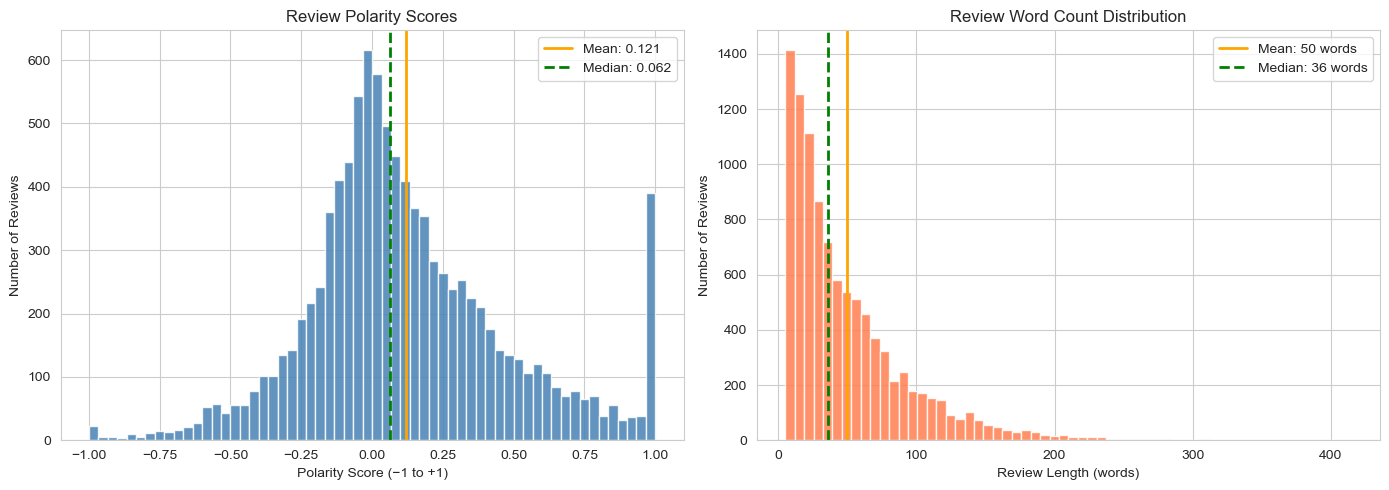

Polarity scores:
  Mean: 0.121  |  Median: 0.062
  Skew: 0.466  (positive = right-skewed; negative = left-skewed)

Review lengths:
  Mean: 49.7 words  |  Median: 36 words
  Skew: 1.993


In [5]:
# Plot the polarity and review-length distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: polarity scores ---
ax1 = axes[0]
ax1.hist(reviews_df['polarity'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(reviews_df['polarity'].mean(), color='orange', linewidth=2,
            label=f"Mean: {reviews_df['polarity'].mean():.3f}")
ax1.axvline(reviews_df['polarity'].median(), color='green', linewidth=2, linestyle='--',
            label=f"Median: {reviews_df['polarity'].median():.3f}")
ax1.set_xlabel("Polarity Score (−1 to +1)")
ax1.set_ylabel("Number of Reviews")
ax1.set_title("Review Polarity Scores")
ax1.legend()

# --- Right panel: review word counts ---
ax2 = axes[1]
ax2.hist(reviews_df['word_count'], bins=60, color='coral', edgecolor='white', alpha=0.85)
ax2.axvline(reviews_df['word_count'].mean(), color='orange', linewidth=2,
            label=f"Mean: {reviews_df['word_count'].mean():.0f} words")
ax2.axvline(reviews_df['word_count'].median(), color='green', linewidth=2, linestyle='--',
            label=f"Median: {reviews_df['word_count'].median():.0f} words")
ax2.set_xlabel("Review Length (words)")
ax2.set_ylabel("Number of Reviews")
ax2.set_title("Review Word Count Distribution")
ax2.legend()

plt.tight_layout()
plt.show()

print("Polarity scores:")
print(f"  Mean: {reviews_df['polarity'].mean():.3f}  |  Median: {reviews_df['polarity'].median():.3f}")
print(f"  Skew: {reviews_df['polarity'].skew():.3f}  (positive = right-skewed; negative = left-skewed)")
print()
print("Review lengths:")
print(f"  Mean: {reviews_df['word_count'].mean():.1f} words  |  Median: {reviews_df['word_count'].median():.0f} words")
print(f"  Skew: {reviews_df['word_count'].skew():.3f}")


### 💡 What do you notice?

- **Polarity scores are mildly right-skewed** — there is a long tail to the right (very positive reviews) and most reviews cluster in the mildly-positive range. The mean is pulled upward by those extreme positive values.
- **Review lengths are strongly right-skewed** — most reviews are short (under 60 words), but a long tail of very long reviews stretches to the right. The mean length is noticeably higher than the median because those long reviews pull the average up.

**Back to our scenario:**
> If Priya asks "how long is a typical review?", the median (around 40 words) is more honest than the mean (pulled higher by a few very long complaints). This is exactly the kind of nuance that separates a useful data analyst from one who just runs code.

## ✅ Section Summary

| Concept | What it means | Real-world use |
|---|---|---|
| **Distribution** | The pattern of how often each value appears in a dataset | Understanding what "normal" looks like before flagging anomalies |
| **Normal (bell curve)** | Symmetric, mean ≈ median, thin tails | Heights, test scores, measurement errors |
| **Right-skewed** | Long tail to the right, mean > median | Incomes, review lengths, house prices |
| **Left-skewed** | Long tail to the left, mean < median | Easy exam scores, age at retirement |
| **Mean vs Median** | Mean is sensitive to extremes; median is resistant | Always check both when the distribution might be skewed |

**Key insight for our scenario:**
> Sarah's polarity scores are mildly right-skewed — the median is the more representative summary for Priya. *Knowing the shape of the data is step one of any serious ML project.*

---
**Up next → Part 2:** Wednesday — Sarah labels 200 reviews by hand and learns to put a confidence bracket around her 84% accuracy.
Open `03_confidence_intervals.ipynb`

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

This optional section covers:
- **Z-scores** — how to flag unusual values (a key feature-standardisation technique used in ML)

## 🎯 Z-scores: Measuring How Unusual a Value Is

**The idea in plain English:**
> A Z-score answers: *"How many standard deviations away from the average is this value?"*
> Z = 0 means exactly average. Z = 2 means "two standard deviations above average." Z = −3 means "very far below average."

**Standard deviation — a quick recap:**
Standard deviation measures how spread out values are around the mean. A small standard deviation means most values sit close to the average; a large one means they are spread widely. For example, two classes both average 70 on a test: one has scores ranging 68–72 (tiny standard deviation), the other ranges 40–100 (large standard deviation). The Z-score uses this spread as its unit of measurement, so you can instantly see how unusual any single value is relative to the rest of the data.

**Formula:**
```
z = (value − mean) / standard deviation
```

**The exam score analogy:** You score 85 on an exam. Is that good?
- If the class average was 60 and the standard deviation was 10 → Z = (85−60)/10 = **2.5** — top 1% of the class.
- If the class average was 82 and the standard deviation was 2 → Z = (85−82)/2 = **1.5** — above average, but not exceptional.
The raw score means nothing without context; the Z-score provides that context instantly.

**Why it matters for ML:**
Z-scores are the foundation of *feature standardisation* — one of the most common preprocessing steps before training a model. This works for **any** distribution shape.

Z-scores are also used in outlier detection, where |Z| > 3 is a common rule of thumb for flagging unusual values. **Important caveat:** this threshold only works reliably when the data is approximately normally distributed. For skewed data, the rule misleads — the skew shifts where extreme values land relative to the mean and standard deviation, so the |Z| > 3 boundary is no longer a meaningful cut-off. We will see this play out in the example below.

In [6]:
# Compute Z-scores for the polarity scores
pol_mean = polarity_scores.mean()
pol_std  = polarity_scores.std()

reviews_df['z_score'] = (reviews_df['polarity'] - pol_mean) / pol_std

# Show some examples
print(f"Population mean: {pol_mean:.4f}")
print(f"Population std:  {pol_std:.4f}")
print()
print("Example Z-scores:")
examples = reviews_df.nlargest(3, 'z_score')[['polarity','z_score','label']].round(3)
examples2 = reviews_df.nsmallest(3, 'z_score')[['polarity','z_score','label']].round(3)
print("  Most positive reviews:")
print(examples.to_string(index=False))
print()
print("  Most negative reviews:")
print(examples2.to_string(index=False))


Population mean: 0.1206
Population std:  0.3564

Example Z-scores:
  Most positive reviews:
 polarity  z_score    label
      1.0    2.467 POSITIVE
      1.0    2.467 POSITIVE
      1.0    2.467 POSITIVE

  Most negative reviews:
 polarity  z_score    label
     -1.0   -3.144 NEGATIVE
     -1.0   -3.144 NEGATIVE
     -1.0   -3.144 NEGATIVE


Reviews with |Z| > 3.0: 27 (0.27%)
  ...of which 0 are unusually POSITIVE (Z > +3)
  ...and       27 are unusually NEGATIVE (Z < -3)



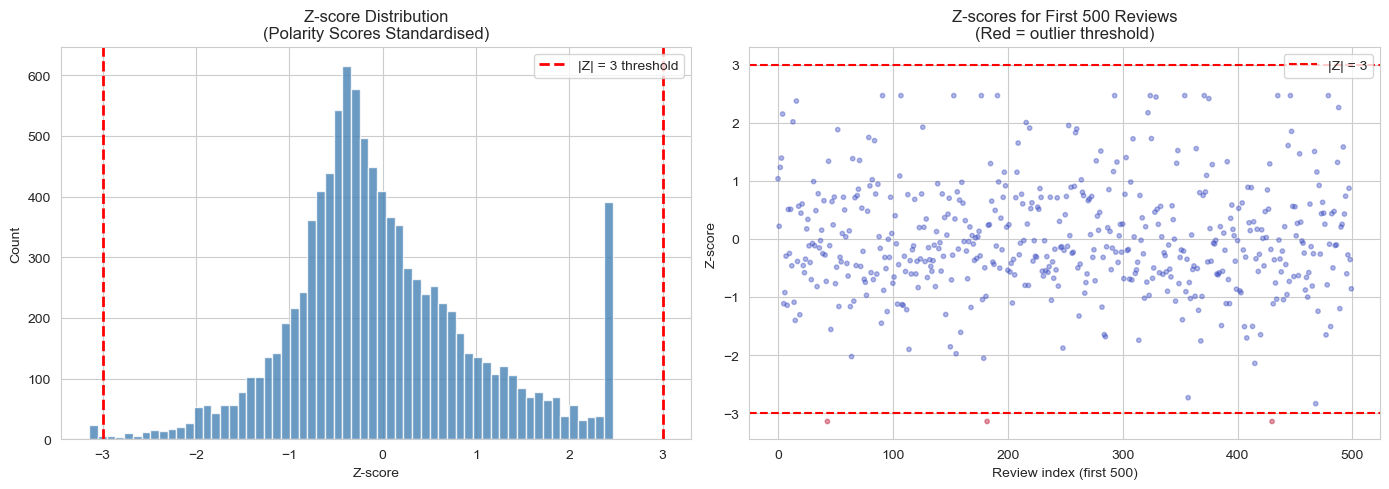

Z-score range in this dataset:
  Most positive Z: 2.467  (hard ceiling — polarity model caps at +1.0)
  Most negative Z: -3.144

Note: this right-skewed distribution with a ceiling at +1.0 is not well-suited
for Z-score outlier detection. See the observations cell below for why.


In [8]:
# Identify outliers using Z-score threshold
outlier_threshold = 3.0
outliers = reviews_df[np.abs(reviews_df['z_score']) > outlier_threshold]
n_pos_outliers = (reviews_df['z_score'] >  outlier_threshold).sum()
n_neg_outliers = (reviews_df['z_score'] < -outlier_threshold).sum()

print(f"Reviews with |Z| > {outlier_threshold}: {len(outliers)} ({len(outliers)/len(reviews_df):.2%})")
print(f"  ...of which {n_pos_outliers} are unusually POSITIVE (Z > +3)")
print(f"  ...and       {n_neg_outliers} are unusually NEGATIVE (Z < -3)")
print()

# Visualise Z-score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(reviews_df['z_score'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(-3, color='red', linewidth=2, linestyle='--', label='|Z| = 3 threshold')
ax1.axvline(3, color='red', linewidth=2, linestyle='--')
ax1.set_xlabel("Z-score")
ax1.set_ylabel("Count")
ax1.set_title("Z-score Distribution\n(Polarity Scores Standardised)")
ax1.legend()

ax2 = axes[1]
ax2.scatter(reviews_df.index[:500], reviews_df['z_score'][:500],
            c=np.abs(reviews_df['z_score'][:500]) > 3,
            cmap='coolwarm', alpha=0.4, s=10)
ax2.axhline(3, color='red', linewidth=1.5, linestyle='--', label='|Z| = 3')
ax2.axhline(-3, color='red', linewidth=1.5, linestyle='--')
ax2.set_xlabel("Review index (first 500)")
ax2.set_ylabel("Z-score")
ax2.set_title("Z-scores for First 500 Reviews\n(Red = outlier threshold)")
ax2.legend()

plt.tight_layout()
plt.show()

print("Z-score range in this dataset:")
print(f"  Most positive Z: {reviews_df['z_score'].max():.3f}  (hard ceiling — polarity model caps at +1.0)")
print(f"  Most negative Z: {reviews_df['z_score'].min():.3f}")
print()
print("Note: this right-skewed distribution with a ceiling at +1.0 is not well-suited")
print("for Z-score outlier detection. See the observations cell below for why.")

### 💡 What do you notice?

- **Z-scores standardise the data** — regardless of the original scale, the distribution is recentred at 0 and measured in standard deviation units. This is useful for feature standardisation in ML pipelines and works for any distribution shape.
- **The outliers are all on the negative side** — there's no Z above +3, but a handful of reviews sit below −3. The reason is structural: the sentiment model caps scores at +1.0, so the highest achievable Z-score for any positive review is approximately +2.5. No amount of enthusiasm can push a review past that ceiling.
- **⚠️ This example reveals why |Z| > 3 is a poor outlier rule for skewed data.** Two properties of this dataset break the assumption: (1) the distribution is right-skewed, not normal, and (2) there is a hard ceiling at +1.0 that prevents extreme positive Z-scores from ever forming. The asymmetric result — negatives flagged, positives never flagged — is an artefact of these properties, not a genuine signal. For skewed data, **IQR-based outlier detection** (using the interquartile range) is more reliable because it makes no assumption about distribution shape.

**Key takeaway:**
> Check the distribution shape *before* choosing an outlier detection method. Z-score thresholds are designed for approximately normal data. Sarah's polarity scores call for a different approach.